In [55]:
# case study -4 - potato disease prediction

In [56]:
# VGG 
# VGG16 ,19            # 16 convolcation alyer and 3 dense layer
# by visual geometry group
# very deep network
# VGG16 >> 13 Convolution layers ,3 Fully Connected layers >> image size 224,224,3
# VGG19 >> 16 Convolution layers ,3 Fully Connected layers >> image size 224,224,3

# imgenet >>> datatset


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import cv2
import os
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,Input


In [ ]:
path=r".\PlantVillage"

In [59]:
from pathlib import Path

In [60]:
win_path=Path(path)

In [61]:
floders=list(win_path.glob('*'))

In [62]:
floders

[WindowsPath('D:/dataset/PlantVillage/Potato___Early_blight'),
 WindowsPath('D:/dataset/PlantVillage/Potato___healthy'),
 WindowsPath('D:/dataset/PlantVillage/Potato___Late_blight')]

In [63]:
all_images=list(win_path.glob('*/*.jpg'))

In [64]:
len(all_images)

2150

In [65]:
# all above golb method is just check for all image size

In [66]:
# step -1  create imagedatagenerator object

In [67]:
# step 1 create object of image data generator
# rescale
# validation split
# data aug >> paramter shear flip

In [68]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   # 80% train , 20% validation
    rotation_range=20,   #below data agumentation concept
    zoom_range=0.2,
    horizontal_flip=True
)

In [69]:
train_data=datagen.flow_from_directory(
    path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

Found 1721 images belonging to 3 classes.


In [70]:
test_data=datagen.flow_from_directory(
    path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

Found 429 images belonging to 3 classes.


In [71]:
1721+429

2150

In [72]:
for i,j in train_data:
    print(i.shape,j.shape)
    break

(32, 224, 224, 3) (32, 3)


In [73]:
class_dict=train_data.class_indices

In [74]:
class_dict

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [75]:
class_names=list(train_data.class_indices.keys())

In [76]:
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

Potato___Early_blight


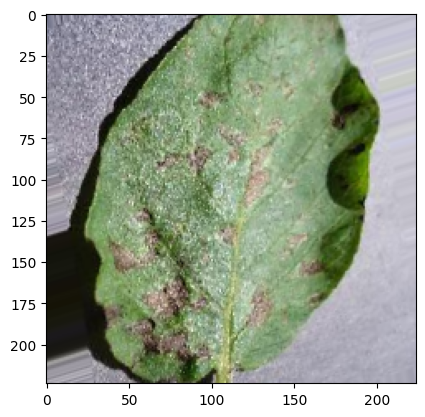

In [77]:
for i,j,in train_data:
    plt.imshow(i[0])
    print(class_names[np.argmax(j[0])])
    break

In [78]:
s1=pd.Series(train_data.classes)

In [79]:
s1.value_counts()

0    800
1    800
2    121
Name: count, dtype: int64

In [80]:
#dataset is balanced

In [81]:
# model training

In [82]:
from tensorflow.keras.applications import VGG16,VGG19

In [83]:
base_model=VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)

)
    

In [84]:
# 16 convolutions layers, 3 dense layers 

In [85]:
# 16 layers >> Freeze  means retrain nhi hoga
# Why freeze
# We only want to train our new classification layers(fully connected layers)
# We don’t want to re-train the pre-trained knowledge





In [86]:
for layer in base_model.layers:
    layer.trainable = False

In [87]:
final_model=keras.Sequential([
    base_model,
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(3,activation='softmax')
])

In [88]:
final_model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])


In [89]:
final_model.fit(
    train_data,
    epochs=1,
    validation_data=test_data
)

54/54 ━━━━━━━━━━━━━━━━━━━━ 408s 8s/step - accuracy: 0.6723 - loss: 0.9452 - val_accuracy: 0.8765 - val_loss: 0.4308


In [90]:
final_model.evaluate(test_data)

14/14 ━━━━━━━━━━━━━━━━━━━━ 78s 6s/step - accuracy: 0.8648 - loss: 0.4475


[0.44748929142951965, 0.8648018836975098]

In [91]:
y_pred=final_model.predict(test_data)
y_pred1=[ np.argmax(i) for i in y_pred]

14/14 ━━━━━━━━━━━━━━━━━━━━ 77s 5s/step


In [92]:
# y_pred1

In [93]:
y_test=test_data.classes

In [94]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [95]:
print(confusion_matrix(y_test,y_pred1))

[[188  11   0]
 [ 14 186   0]
 [ 16  14   0]]


In [96]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       199
           1       0.88      0.93      0.91       200
           2       0.00      0.00      0.00        30

    accuracy                           0.87       429
   macro avg       0.58      0.62      0.60       429
weighted avg       0.81      0.87      0.84       429



d:\itvproject\potato_disease_prediction\potenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\itvproject\potato_disease_prediction\potenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\itvproject\potato_disease_prediction\potenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [97]:
# new image

In [98]:
final_model.save('vgg19_potato.keras')

In [99]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
path=r"C:\Users\BusinessComputers.in\Desktop\Potato Late_blight.jpg"
img1=load_img(path,target_size=(224,224))
img2=img_to_array(img1)
img3=img2/255.0
img4=np.expand_dims(img3,axis=0)  
img4.shape
class_names[np.argmax(final_model.predict(img4))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step


'Potato___Early_blight'